In [1]:
import csv
import os 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch

In [2]:
os.chdir(os.getenv("PYTHONPATH"))
!pwd

/Users/miguelmartins/Projects/ESSL-identifiability


In [3]:
log_path = os.path.join(os.getcwd(), "Equivariant_Network/logs/0")

In [4]:
logs = np.array(os.listdir(log_path))

In [5]:
probe_idx = np.char.endswith(logs, '_probe.csv')
pre_idx = ~probe_idx

In [6]:
probes = [os.path.join(log_path, x) for x in logs[probe_idx]]
pretrain = [os.path.join(log_path, x) for x in logs[pre_idx]]

In [7]:
probes, pretrain

(['/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr3_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_none_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr2_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_crop_c4.yaml_202511141253_pr

In [8]:

def get_df(file_path):
    # --- Step 1: Read the file lines
    # Read raw rows with csv to be robust to commas/quotes
    with open(file_path, newline="") as f:
        rows = list(csv.reader(f))
    
    # Find the table header row ("epoch,train_acc,...")
    header_idx = next(i for i, r in enumerate(rows) if r and r[0].strip() == "epoch")
    
    # --- Parse metadata safely (only rows with exactly two cells)
    metadata = {}
    for r in rows[:header_idx]:
        if len(r) == 2:  # skip lines like ['""'] or ['']
            k, v = r
            metadata[k.strip()] = v.strip()
    
    # --- Parse the training table
    header = rows[header_idx]
    data = rows[header_idx + 1:]
    df = pd.DataFrame(data, columns=header)
    
    # Make numeric columns numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    
    return df

In [9]:
def get_c4(logs):
    return np.array(sorted([x for x in logs if "c4" in x]))

In [23]:
probes_c4 = get_c4(probes)
pretrain_c4 = get_c4(pretrain)

In [24]:
probes_c4

array(['/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_crop_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_none_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr2_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr3_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup_c4.yaml_202511141253_probe.csv'],
      dtype='<U123')

In [26]:
probes_c4 = get_c4(probes)
pretrain_c4 = get_c4(pretrain)
probes_c4 = probes_c4[[1, 0, 5, 4, 2, 3]]
pretrain_c4 = pretrain_c4[[1, 0, 5, 4, 2, 3]]
probes_c4

array(['/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_none_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_crop_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr2_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr3_c4.yaml_202511141253_probe.csv'],
      dtype='<U123')

In [27]:
names = ["none", "crop", "sup", "simclr", "simclr2", "simclr3"]

In [28]:
get_df(probes_c4[0]), get_df(pretrain[1])

(     epoch  train_loss  train_acc  test_acc  adv_acc  rot_acc
 0        0         NaN    0.50860    0.6094   0.5169      NaN
 1        1         NaN    0.62512    0.6563   0.5873      NaN
 2        2         NaN    0.65162    0.6403   0.5774      NaN
 3        3         NaN    0.66550    0.6665   0.5741      NaN
 4        4         NaN    0.67280    0.6377   0.5692      NaN
 ..     ...         ...        ...       ...      ...      ...
 195    195         NaN    0.72990    0.7130   0.6408      NaN
 196    196         NaN    0.73006    0.7146   0.6386      NaN
 197    197         NaN    0.73144    0.7142   0.6382      NaN
 198    198         NaN    0.73040    0.7154   0.6456      NaN
 199    199         NaN    0.72902    0.7128   0.6360      NaN
 
 [200 rows x 6 columns],
      epoch  train_loss  train_acc  test_acc  adv_acc  rot_acc
 0        0         NaN    0.11794    0.1547   0.1527  0.32546
 1        1         NaN    0.14878    0.1828   0.1835  0.39900
 2        2         NaN    0

In [33]:
rot_accs = []
test_accs = []
adv_accs = []
running_avg_size = 10
df_logs = {}
for i in range(len(names)): # we ignore none because i messed up the logs
    downstream = get_df(probes_c4[i])
    pre = get_df(pretrain_c4[i])
    rot_acc = np.mean(pre["rot_acc"].values[-running_avg_size:])
    test_acc = np.mean(downstream["test_acc"].values[-running_avg_size:])
    adv_acc = np.mean(downstream["adv_acc"].values[-running_avg_size:])
    df_logs[names[i]] = {"rotation": rot_acc, "probe": test_acc, "probe_adv": adv_acc}

df_logs = pd.DataFrame(df_logs).T
    #rot_acc = np.mean(downstream[-running_avg_size:])
    #rot_acc = np.mean(downstream[-running_avg_size:])

In [34]:
print(df_logs)

         rotation    probe  probe_adv
none     1.000000  0.71346    0.63995
crop     1.000000  0.72594    0.64498
sup      1.000000  0.79750    0.72181
simclr   0.931224  0.84391    0.80821
simclr2  0.913206  0.83925    0.82618
simclr3  0.877946  0.81042    0.80553


In [37]:
import itertools
metrics = ["rotation", "probe", "probe_adv"]
def pareto_mask(df, cols):
    vals = df[cols].to_numpy()
    n = vals.shape[0]
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            # j dominates i (we assume **higher is better** for every metric)
            if np.all(vals[j] >= vals[i]) and np.any(vals[j] > vals[i]):
                is_pareto[i] = False
                break
    return is_pareto

mask_pareto = pareto_mask(df_logs, metrics)
pareto_df = df_logs[mask_pareto]


In [57]:
df_logs

,probe,probe_adv,rotation
none,0.71346,0.63995,1.000000
crop,0.72594,0.64498,1.000000
sup,0.79750,0.72181,1.000000
simclr,0.84391,0.80821,0.931224
simclr2,0.83925,0.82618,0.913206
simclr3,0.81042,0.80553,0.877946


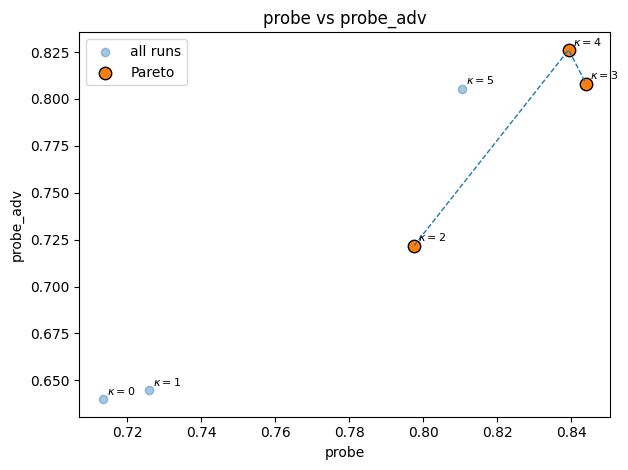

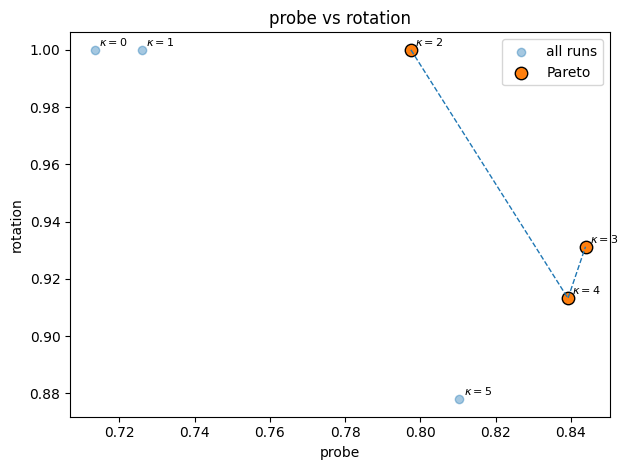

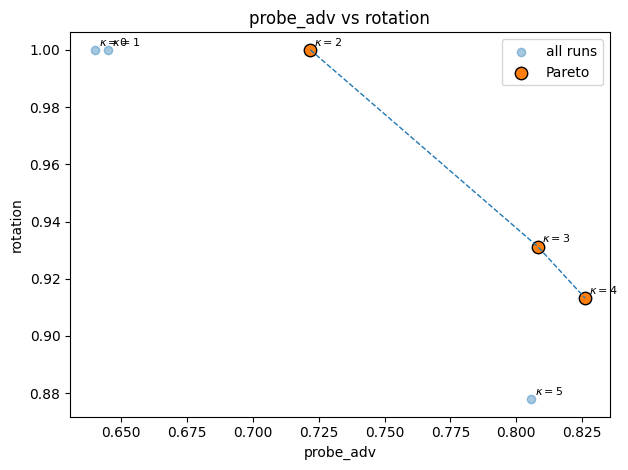

In [56]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

metrics = ["probe", "probe_adv", "rotation", ]
def get_label(idx):
    return name_map.get(idx, str(idx))
name_map = {
    "none": r"$\kappa=0$",
    "crop": r"$\kappa=1$",
    "sup": r"$\kappa=2$",
    "simclr": r"$\kappa=3$",
    "simclr2": r"$\kappa=4$",
    "simclr3": r"$\kappa=5$",
}

def pareto_mask(df, cols):
    vals = df[cols].to_numpy()
    n = vals.shape[0]
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            if np.all(vals[j] >= vals[i]) and np.any(vals[j] > vals[i]):
                is_pareto[i] = False
                break
    return is_pareto

df_logs = df_logs[metrics]   # whatever order you want
mask_pareto = pareto_mask(df_logs, metrics)
pareto_df = df_logs[mask_pareto]
pareto_df = pareto_df[new_order]


for x_col, y_col in itertools.combinations(metrics, 2):
    fig, ax = plt.subplots()

    # all points
    ax.scatter(
        df_logs[x_col],
        df_logs[y_col],
        alpha=0.4,
        label="all runs"
    )

    # Pareto points highlighted
    ax.scatter(
        pareto_df[x_col],
        pareto_df[y_col],
        s=80,
        edgecolor="black",
        label="Pareto"
    )

    # connect Pareto points with a frontier curve (sorted in x)
    pf_sorted = pareto_df.sort_values(by=x_col)
    ax.plot(
        pf_sorted[x_col],
        pf_sorted[y_col],
        linestyle="--",
        linewidth=1
    )

    # --- LABEL **ALL** POINTS (using custom names if provided) ---
    for idx, row in df_logs.iterrows():
        ax.annotate(
            get_label(idx),
            (row[x_col], row[y_col]),
            textcoords="offset points",
            xytext=(3, 3),
            fontsize=8,
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.legend()
    plt.tight_layout()


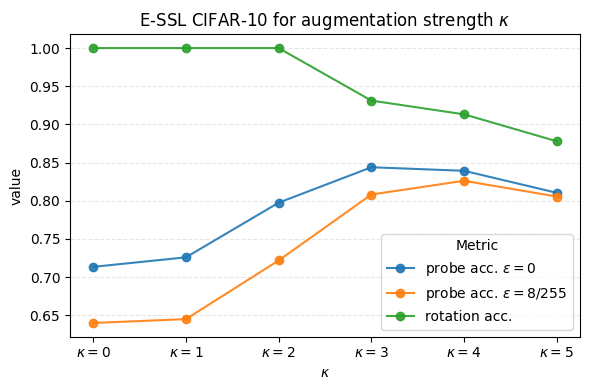

In [65]:
x = np.arange(len(df_logs))                # one x point per κ

fig, ax = plt.subplots(figsize=(6, 4))

y_label = [r"probe acc. $\epsilon=0$", 
           r"probe acc. $\epsilon=8/255$", 
           r"rotation acc."]
# one line per metric, evaluated for all κ values
for i, metric in enumerate(metrics):
    y = df_logs[metric].values
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=1.5,
        label=y_label[i],
        alpha=0.9,
    )

# x-axis ticks are your κ labels
ax.set_xticks(x)
ax.set_xticklabels([name_map[idx] for idx in df_logs.index])

ax.set_ylabel("value")
ax.set_xlabel(r"$\kappa$")
ax.set_title("E-SSL CIFAR-10 for augmentation strength $\kappa$")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

/var/folders/cr/qd8xdw991dv9ypjzzwsktpqc0000gn/T/ipykernel_65191/2332174082.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x[i], y[i], labels[i], fontsize=12, ha='right')
/var/folders/cr/qd8xdw991dv9ypjzzwsktpqc0000gn/T/ipykernel_65191/2332174082.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_sorted = x[sorted_indices]
/var/folders/cr/qd8xdw991dv9ypjzzwsktpqc0000gn/T/ipykernel_65191/2332174082.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

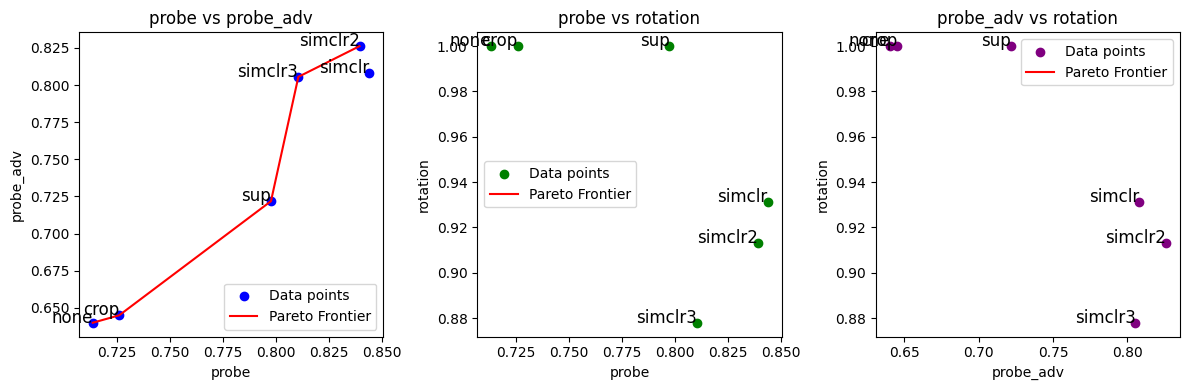

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_pareto_frontiers(df_logs, axis1, axis2, axis3):
    """
    Generates Pareto frontiers for three different scatter plots based on the columns provided.
    
    Parameters:
        df_logs (pd.DataFrame): DataFrame containing the data for plotting.
        axis1 (str): The column name for the first axis (e.g., 'rotation').
        axis2 (str): The column name for the second axis (e.g., 'probe').
        axis3 (str): The column name for the third axis (e.g., 'probe_adv').
    """
    # Extracting the relevant columns for plotting
    x = df_logs[axis1]
    y = df_logs[axis2]
    z = df_logs[axis3]

    # Function to calculate Pareto frontier
    def pareto_frontier(x, y):
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]
        
        pareto_x = [x_sorted[0]]
        pareto_y = [y_sorted[0]]
        
        for i in range(1, len(x_sorted)):
            if y_sorted[i] > pareto_y[-1]:
                pareto_x.append(x_sorted[i])
                pareto_y.append(y_sorted[i])
        
        return np.array(pareto_x), np.array(pareto_y)

    # Function to add labels to each point (using the DataFrame index as labels)
    def add_labels(x, y, labels):
        for i in range(len(x)):
            plt.text(x[i], y[i], labels[i], fontsize=12, ha='right')

    # Plotting Axis1 vs Axis2
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.scatter(x, y, c='blue', label='Data points')
    add_labels(x, y, df_logs.index)  # Use index as labels
    pareto_x, pareto_y = pareto_frontier(x, y)
    plt.plot(pareto_x, pareto_y, color='red', label='Pareto Frontier')
    plt.xlabel(axis1)
    plt.ylabel(axis2)
    plt.title(f'{axis1} vs {axis2}')
    plt.legend()

    # Plotting Axis1 vs Axis3
    plt.subplot(1, 3, 2)
    plt.scatter(x, z, c='green', label='Data points')
    add_labels(x, z, df_logs.index)  # Use index as labels
    pareto_x, pareto_y = pareto_frontier(x, z)
    plt.plot(pareto_x, pareto_y, color='red', label='Pareto Frontier')
    plt.xlabel(axis1)
    plt.ylabel(axis3)
    plt.title(f'{axis1} vs {axis3}')
    plt.legend()

    # Plotting Axis2 vs Axis3
    plt.subplot(1, 3, 3)
    plt.scatter(y, z, c='purple', label='Data points')
    add_labels(y, z, df_logs.index)  # Use index as labels
    pareto_x, pareto_y = pareto_frontier(y, z)
    plt.plot(pareto_x, pareto_y, color='red', label='Pareto Frontier')
    plt.xlabel(axis2)
    plt.ylabel(axis3)
    plt.title(f'{axis2} vs {axis3}')
    plt.legend()

    # Display the plots
    plt.tight_layout()
    plt.show()


# Call the function (you can switch the axis columns as needed)
plot_pareto_frontiers(df_logs,axis1='probe', axis2='probe_adv', axis3='rotation')



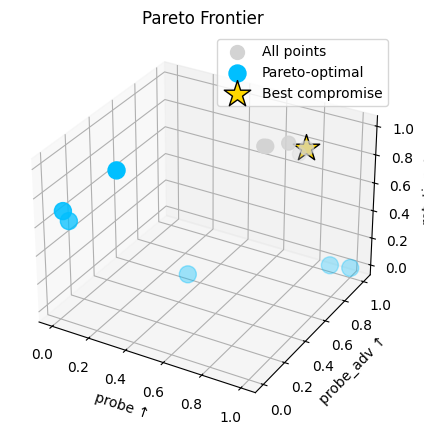

rotation     0.931224
probe        0.843910
probe_adv    0.808210
Name: simclr, dtype: float64

In [32]:
from scipy.spatial import ConvexHull
import numpy as np

def pareto_frontier_3d(values):
    # Using Convex Hull to find the Pareto frontier in 3D
    hull = ConvexHull(values)
    return values[hull.vertices]

def plot_pareto(df, cols=['probe', 'probe_adv', 'rotation'], maximize=None, weights=None, label_col=None):
    if maximize is None:
        maximize = [False] * len(cols)
    if weights is None:
        weights = [1.0] * len(cols)
    if label_col is None:
        labels = df.index
    else:
        labels = df[label_col]
    
    raw = df[cols].values.copy()

    # Flip signs for maximization objectives
    values = raw.copy()
    for i, mx in enumerate(maximize):
        if mx:
            values[:, i] = -values[:, i]
    
    # Normalize to [0,1]
    v_min = values.min(axis=0)
    v_max = values.max(axis=0)
    v_norm = (values - v_min) / (v_max - v_min + 1e-12)
    
    # Weighted sum for the best compromise
    scores = np.sum(v_norm * weights, axis=1)
    best_idx = np.argmin(scores)
    
    # For 3D, use Convex Hull to determine the Pareto frontier
    pareto_points = pareto_frontier_3d(v_norm)

    # Plotting
    fig = plt.figure(figsize=(15, 5))
    ax = fig.add_subplot(111, projection='3d')

    # All points (gray)
    ax.scatter(raw[:, 0], raw[:, 1], raw[:, 2], c='lightgray', s=100, label='All points')

    # Pareto frontier points (blue)
    ax.scatter(pareto_points[:, 0], pareto_points[:, 1], pareto_points[:, 2], c='deepskyblue', s=150, label='Pareto-optimal')
    
    # Best compromise point (big gold star)
    ax.scatter(raw[best_idx, 0], raw[best_idx, 1], raw[best_idx, 2], c='gold', s=400, marker='*', edgecolor='black', label='Best compromise')

    ax.set_xlabel(f"{cols[0]} {'↑' if maximize[0] else '↓'}")
    ax.set_ylabel(f"{cols[1]} {'↑' if maximize[1] else '↓'}")
    ax.set_zlabel(f"{cols[2]} {'↑' if maximize[2] else '↓'}")
    ax.set_title('Pareto Frontier')
    ax.legend()

    plt.show()

    return df.iloc[best_idx]
plot_pareto(
    df_logs,
    cols=['probe', 'probe_adv', 'rotation'],
    maximize=[True, True, True],     # ↑ ↑ ↓
    weights=[1.0, 1.0, 1.0]           # we care most about adversarial robustness
)